# IMPORTE REQUIRED LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,roc_curve,roc_auc_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score,ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler

# LOAD DATASET

In [146]:
df=pd.read_csv(r"D:\windows iso\stroke.csv")

# DATASET OVERVIEW

In [147]:
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [148]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


# DATA CLEANING

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [150]:
df.drop("id",axis=1,inplace=True)

In [151]:
df["bmi"]=df["bmi"].fillna(df["bmi"].median())

In [152]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [153]:
df.head(15)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,Female,59.0,0,0,Yes,Private,Rural,76.15,28.1,Unknown,1
9,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [154]:
df["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [155]:
df=df[df["gender"]!="Other"]

In [156]:
df["hypertension"].value_counts()

hypertension
0    4611
1     498
Name: count, dtype: int64

In [157]:
df["heart_disease"].value_counts()

heart_disease
0    4833
1     276
Name: count, dtype: int64

In [158]:
df.tail(25)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5085,Female,72.00,0,0,Yes,Private,Urban,83.89,33.1,formerly smoked,0
5086,Female,51.00,0,0,Yes,Private,Urban,152.56,21.8,Unknown,0
5087,Female,63.00,0,0,Yes,Self-employed,Rural,75.93,34.7,formerly smoked,0
5088,Female,64.00,1,0,Yes,Self-employed,Urban,76.89,30.2,Unknown,0
5089,Female,0.72,0,0,No,children,Rural,62.13,16.8,Unknown,0
5090,Male,26.00,0,0,No,Govt_job,Rural,100.85,21.0,smokes,0
5091,Male,59.00,1,0,Yes,Private,Rural,95.05,30.9,never smoked,0
5092,Male,76.00,0,0,Yes,Govt_job,Urban,82.35,38.9,never smoked,0
5093,Female,45.00,1,0,Yes,Govt_job,Rural,95.02,28.1,smokes,0
5094,Male,13.00,0,0,No,children,Urban,82.38,24.3,Unknown,0


In [159]:
df["work_type"].value_counts()

work_type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [160]:
df["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

# EXPLORATORY DATA ANALYSIS

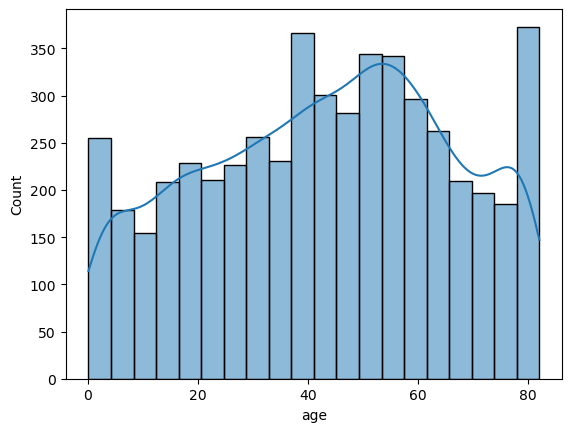

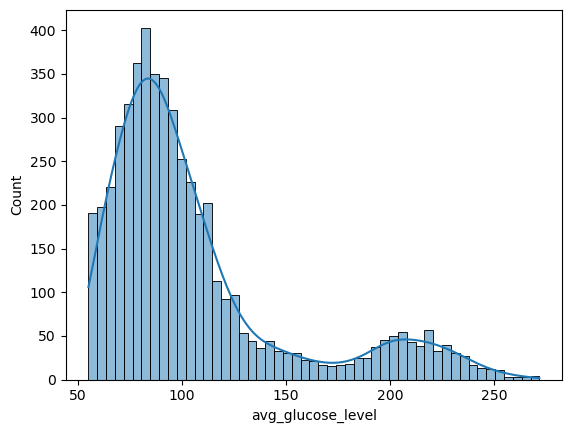

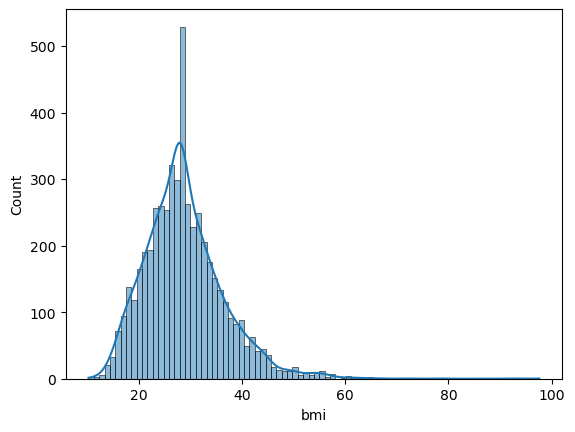

In [161]:
num_cols = ["age", "avg_glucose_level", "bmi"]

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.show()

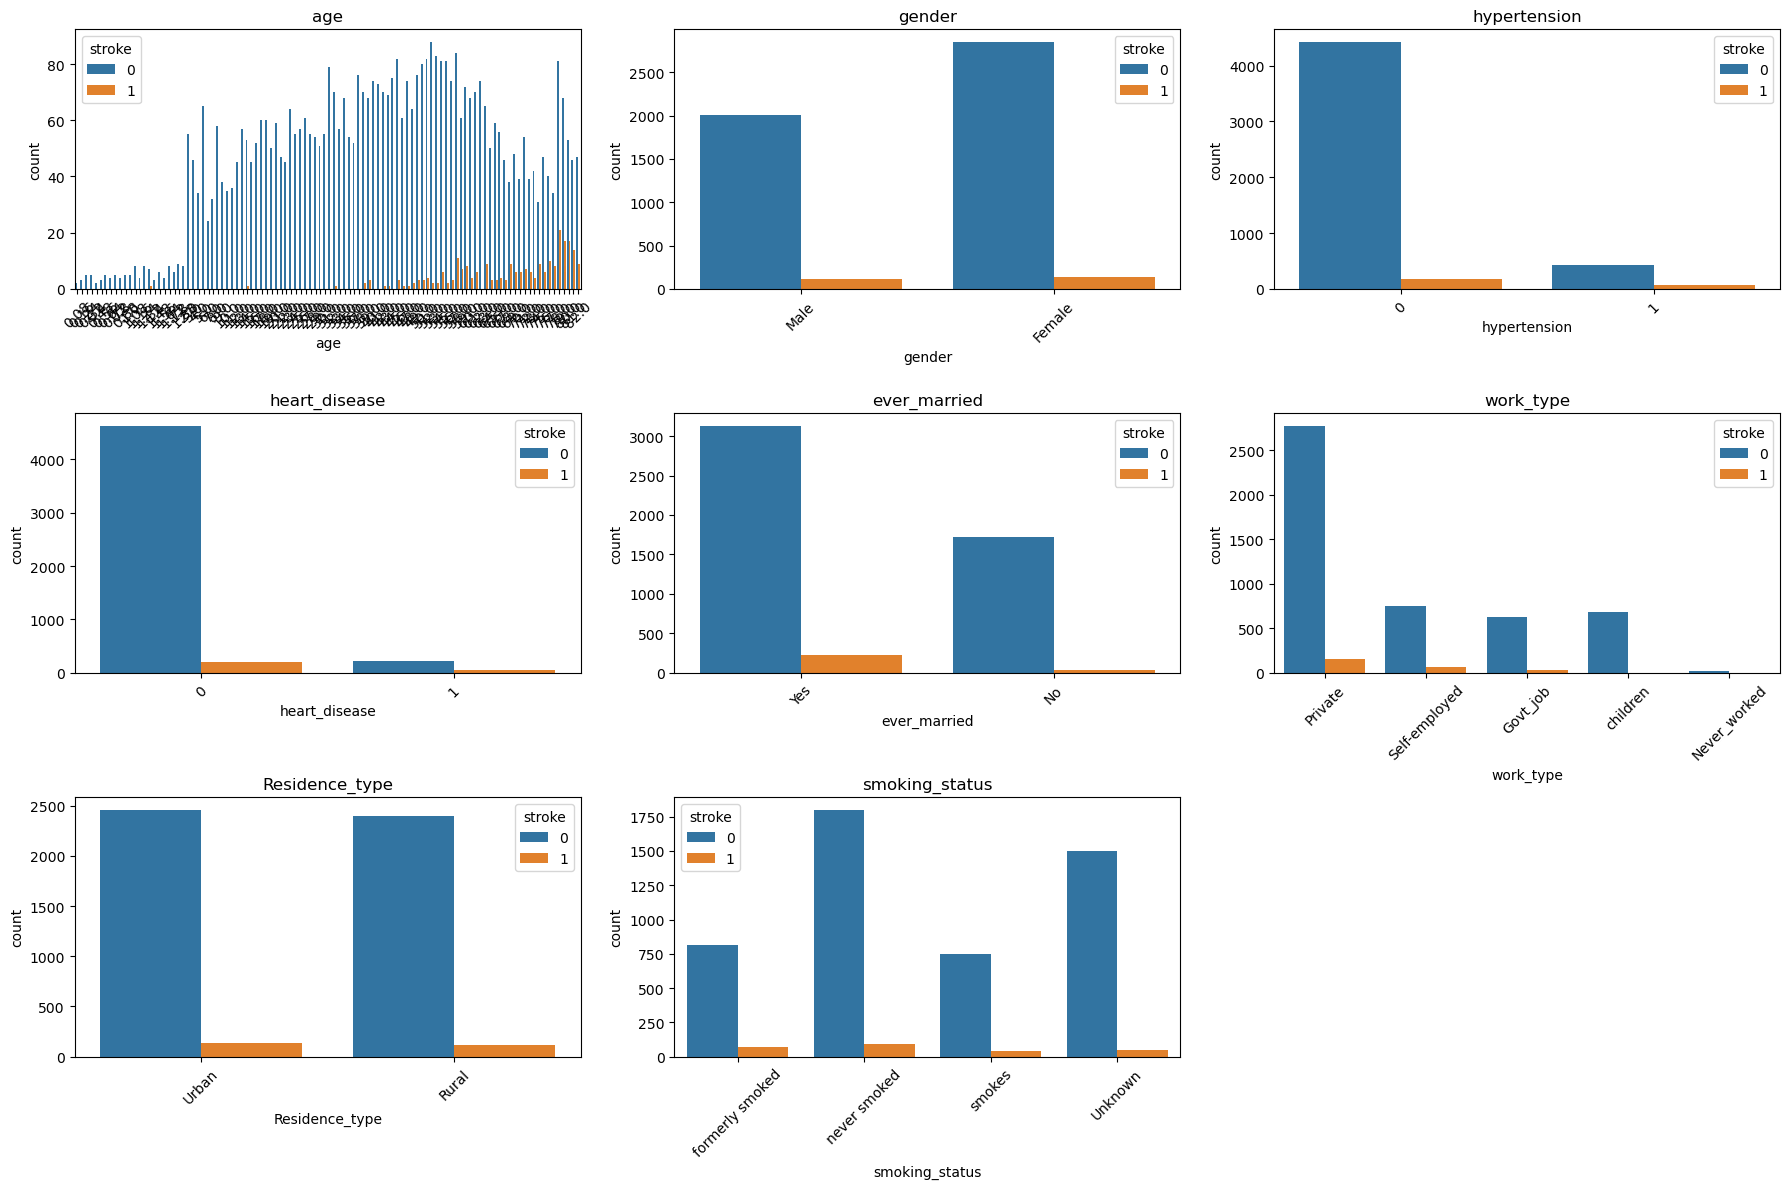

In [162]:
cat_cols = [
    "age",
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        x=col,
        hue="stroke",
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


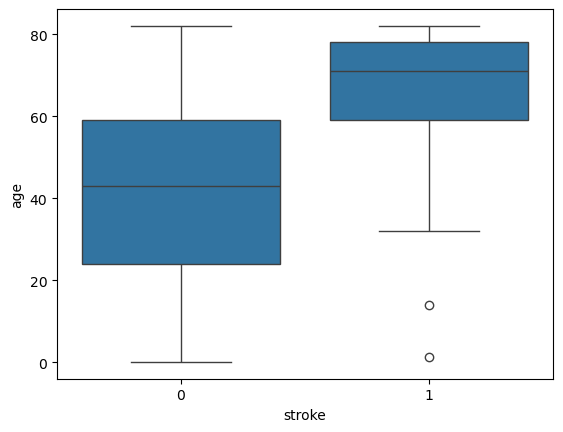

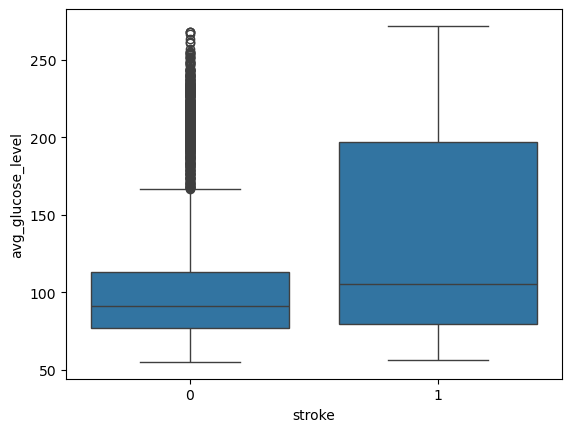

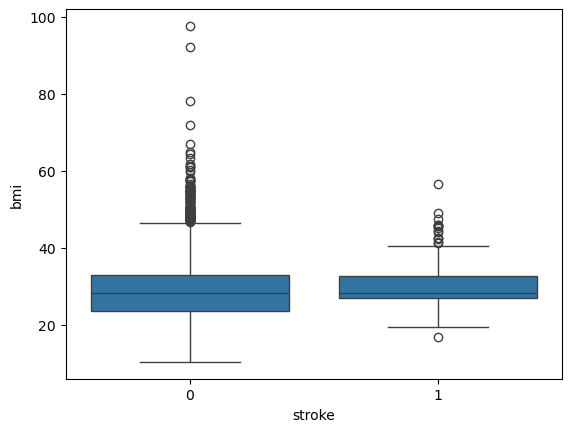

In [163]:
sns.boxplot(x="stroke", y="age", data=df)
plt.show()

sns.boxplot(x="stroke", y="avg_glucose_level", data=df)
plt.show()

sns.boxplot(x="stroke", y="bmi", data=df)
plt.show()

<Axes: xlabel='age', ylabel='bmi'>

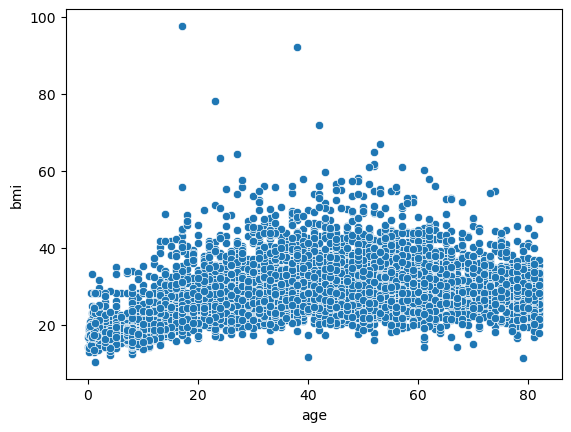

In [164]:
sns.scatterplot(data=df,
                x="age",
                y="bmi")

# FEATURE ENGINEERING AND DATA PREPROCESSING

ENCODING

In [165]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown="ignore")

encoded=encoder.fit_transform(df[["gender","ever_married","work_type","Residence_type","smoking_status"]])


encoded_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out(),index=df.index)

df=df.drop(columns=["gender","ever_married","work_type","Residence_type","smoking_status"])

df=pd.concat([df,encoded_df],axis=1)

print(df.head())

    age  hypertension  heart_disease  avg_glucose_level   bmi  stroke  \
0  67.0             0              1             228.69  36.6       1   
1  61.0             0              0             202.21  28.1       1   
2  80.0             0              1             105.92  32.5       1   
3  49.0             0              0             171.23  34.4       1   
4  79.0             1              0             174.12  24.0       1   

   gender_Female  gender_Male  ever_married_No  ever_married_Yes  ...  \
0            0.0          1.0              0.0               1.0  ...   
1            1.0          0.0              0.0               1.0  ...   
2            0.0          1.0              0.0               1.0  ...   
3            1.0          0.0              0.0               1.0  ...   
4            1.0          0.0              0.0               1.0  ...   

   work_type_Never_worked  work_type_Private  work_type_Self-employed  \
0                     0.0                1.0     

In [166]:
print(df.columns.tolist())

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Female', 'gender_Male', 'ever_married_No', 'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Rural', 'Residence_type_Urban', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5109 non-null   float64
 1   hypertension                    5109 non-null   int64  
 2   heart_disease                   5109 non-null   int64  
 3   avg_glucose_level               5109 non-null   float64
 4   bmi                             5109 non-null   float64
 5   stroke                          5109 non-null   int64  
 6   gender_Female                   5109 non-null   float64
 7   gender_Male                     5109 non-null   float64
 8   ever_married_No                 5109 non-null   float64
 9   ever_married_Yes                5109 non-null   float64
 10  work_type_Govt_job              5109 non-null   float64
 11  work_type_Never_worked          5109 non-null   float64
 12  work_type_Private               5109 no

 SEPERATE FEATURES AND LABELS

In [168]:
x=df.drop(columns="stroke").astype(float)
y=df["stroke"].astype(int)

 TRAIN TEST SPLIT


In [169]:
print(df.shape)

(5109, 21)


In [170]:
print(y.shape)

(5109,)


In [171]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)#stratify is used because of imbalance in dataset.it create same proportion of training and test data.

# Handling Class Imbalance

Under Sampling

In [172]:

rus=RandomUnderSampler(random_state=42,sampling_strategy=0.2)
x_train,y_train=rus.fit_resample(x_train,y_train)

In [173]:
print(y_train.value_counts())

stroke
0    935
1    187
Name: count, dtype: int64


Apply Smote

In [174]:
smote=SMOTE(random_state=42)
x_train,y_train=smote.fit_resample(x_train,y_train)

In [175]:
print(y_train.value_counts())

stroke
0    935
1    935
Name: count, dtype: int64


# Model Building

scaling(standard scaling)

In [176]:
scaler=StandardScaler()
num_cols = ["age", "avg_glucose_level", "bmi"]
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()
x_train_scaled[num_cols]=scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols]=scaler.transform(x_test[num_cols])

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5109 non-null   float64
 1   hypertension                    5109 non-null   int64  
 2   heart_disease                   5109 non-null   int64  
 3   avg_glucose_level               5109 non-null   float64
 4   bmi                             5109 non-null   float64
 5   stroke                          5109 non-null   int64  
 6   gender_Female                   5109 non-null   float64
 7   gender_Male                     5109 non-null   float64
 8   ever_married_No                 5109 non-null   float64
 9   ever_married_Yes                5109 non-null   float64
 10  work_type_Govt_job              5109 non-null   float64
 11  work_type_Never_worked          5109 non-null   float64
 12  work_type_Private               5109 no

Logistic Regression model


In [ ]:


model_1=LogisticRegression(random_state=42,class_weight="balanced",max_iter=1000)
model_1.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred=model_1.predict(x_test_scaled)

In [180]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.7279843444227005


In [181]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[693 267]
 [ 11  51]]


In [182]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.72      0.83       960
           1       0.16      0.82      0.27        62

    accuracy                           0.73      1022
   macro avg       0.57      0.77      0.55      1022
weighted avg       0.93      0.73      0.80      1022



In [183]:
f1 = f1_score(y_test, y_pred)

print("F1-score:", f1)

F1-score: 0.26842105263157895


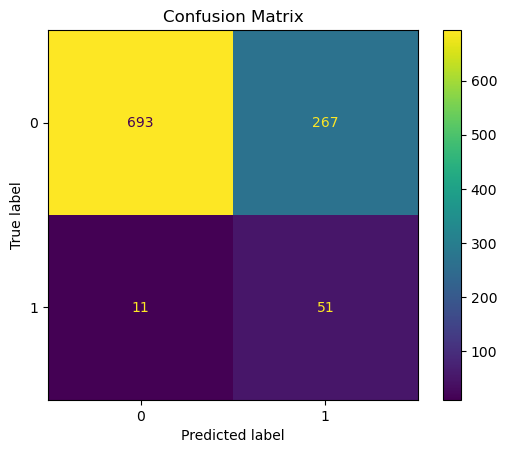

In [ ]:
ConfusionMatrixDisplay.from_estimator(model_1,x_test_scaled,y_test)
plt.title("Confusion Matrix")
plt.show()

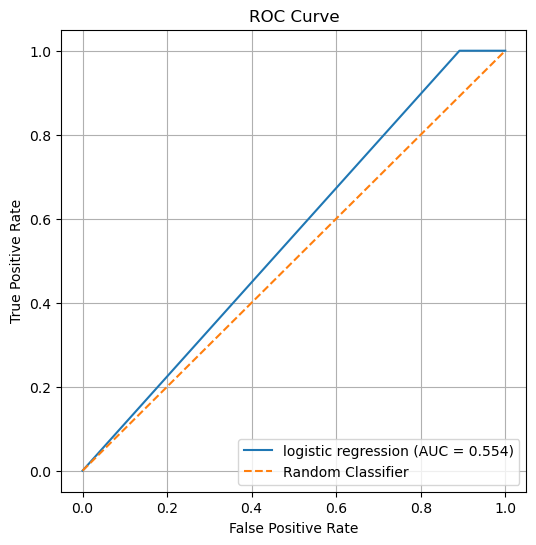

AUC Score: 0.5541666666666667


In [ ]:


# Predict probabilities for the positive class
y_prob = model_1.predict_proba(x_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"logistic regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("AUC Score:", auc_score)

Random Forest

In [186]:
model_2=RandomForestClassifier(random_state=42, n_estimators=200,
    class_weight="balanced",)
model_2.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [187]:
ra_pred=model_2.predict(x_test)
print(confusion_matrix(y_test,ra_pred))
print(classification_report(y_test,ra_pred))

[[895  65]
 [ 46  16]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       960
           1       0.20      0.26      0.22        62

    accuracy                           0.89      1022
   macro avg       0.57      0.60      0.58      1022
weighted avg       0.91      0.89      0.90      1022



In [188]:
accuracy=accuracy_score(y_test,ra_pred)
print(accuracy)

0.8913894324853229


In [189]:
f1 = f1_score(y_test, ra_pred)

print("F1-score:", f1)

F1-score: 0.22377622377622378


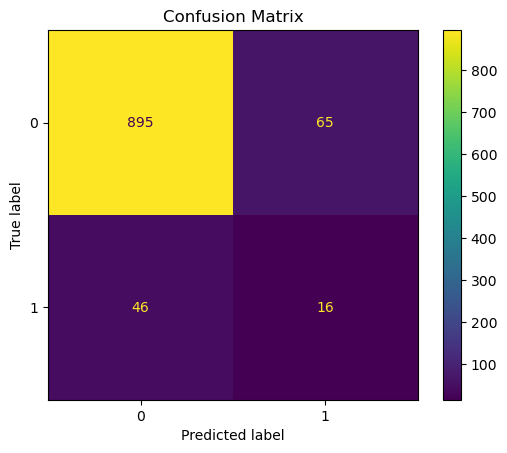

In [190]:
ConfusionMatrixDisplay.from_estimator(model_2,x_test,y_test)
plt.title("Confusion Matrix")
plt.show()

xg  boost

In [191]:
model_3=XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
model_3.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [192]:
xg_pred=model_3.predict(x_test)
print(confusion_matrix(y_test,xg_pred))
print(classification_report(y_test,xg_pred))

[[898  62]
 [ 39  23]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       960
           1       0.27      0.37      0.31        62

    accuracy                           0.90      1022
   macro avg       0.61      0.65      0.63      1022
weighted avg       0.92      0.90      0.91      1022



In [193]:
accuracy=accuracy_score(y_test,xg_pred)
print(accuracy)

0.901174168297456


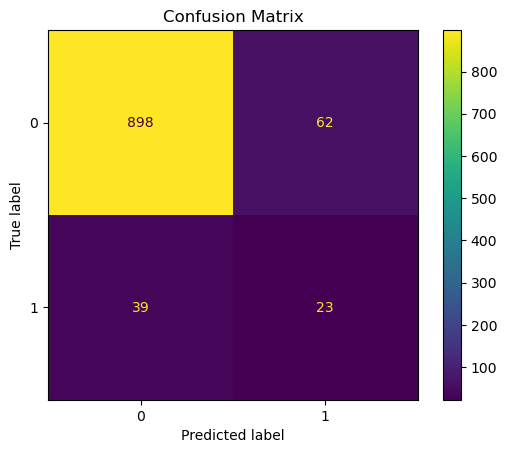

In [194]:
ConfusionMatrixDisplay.from_estimator(model_3,x_test,y_test)
plt.title("Confusion Matrix")
plt.show()

Gradient Boosting

In [195]:
gb=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
gb.fit(x_train,y_train)
gb_pred=gb.predict(x_test)

In [196]:
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("F1 Score:", f1_score(y_test, gb_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, gb_pred))

print("\nClassification Report")
print(classification_report(y_test, gb_pred))

Accuracy: 0.8933463796477495
F1 Score: 0.2684563758389262

Confusion Matrix
[[893  67]
 [ 42  20]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       960
           1       0.23      0.32      0.27        62

    accuracy                           0.89      1022
   macro avg       0.59      0.63      0.61      1022
weighted avg       0.91      0.89      0.90      1022



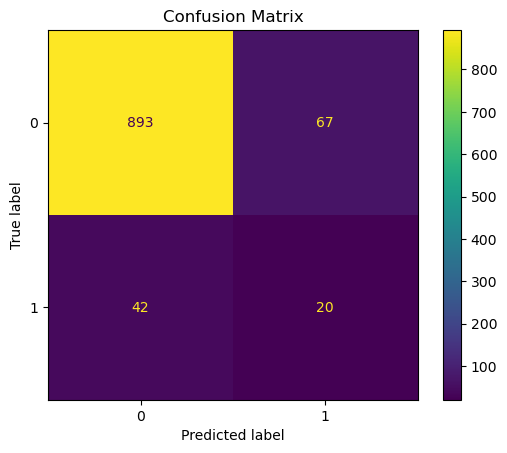

In [197]:
ConfusionMatrixDisplay.from_estimator(gb,x_test,y_test)
plt.title("Confusion Matrix")
plt.show()